In [62]:
# Imports

import matplotlib.pyplot as plt
from matplotlib import colormaps
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors

# load in the results
result_dir = "/Users/katiepambakian/Documents/BSc Computer Science/Y3/Dissertation/BeeCommunication/results/"

# date = "2026-03-12/"
# slurm_job = 16316301

date = "2026-03-16/"
slurm_job = 16340977
batches = [0, 3, 9, 11, 12, 13, 15, 16, 18]

result_dir = result_dir + date + str(slurm_job) + "/"

runs = [0]

# start at line number 1
def read_ith_line(i, filename):
    with open(filename, "r") as file:
        for line_number, line in enumerate(file, start=1):
            if (line_number == i):
                return [float(x) for x in line.strip().split()]
            
    # If file exists but doesn't have that many lines
    return []

In [67]:
colors = ["red", "darkorange", "gold", "greenyellow", "lime"]
cmap = mcolors.LinearSegmentedColormap.from_list("fitness_map", colors)
norm = mcolors.Normalize(vmin=0.995, vmax=1.0)

# get color
def getColor(fitness):

    return cmap(norm(fitness))
    # if (fitness <= 0.95):
    #     return "red"
    # elif (fitness <= 0.96):
    #     return "darkorange"
    # elif (fitness <= 0.97):
    #     return "gold"
    # elif (fitness <= 0.98):
    #     return "greenyellow"
    # else:
    #     return "lime"

0.998866


/var/folders/fz/htwq5qzj5_d0ry3b14hmlrsw0000gn/T/ipykernel_33708/3894627376.py:39: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "go" (-> marker='o'). The keyword argument will take precedence.
  ax.plot(6000,landmark[i], 'go', marker=f"${str(i+1)}$",markersize=40, color="grey")
/var/folders/fz/htwq5qzj5_d0ry3b14hmlrsw0000gn/T/ipykernel_33708/3894627376.py:39: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "go" (-> color='g'). The keyword argument will take precedence.
  ax.plot(6000,landmark[i], 'go', marker=f"${str(i+1)}$",markersize=40, color="grey")
/var/folders/fz/htwq5qzj5_d0ry3b14hmlrsw0000gn/T/ipykernel_33708/3894627376.py:42: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "go" (-> marker='o'). The keyword argument will take precedence.
  ax.plot(6000,landmark[i], 'go',marker=f"${str(i+1)}$",markersize=40,color=color)
/var/folders/fz/htw

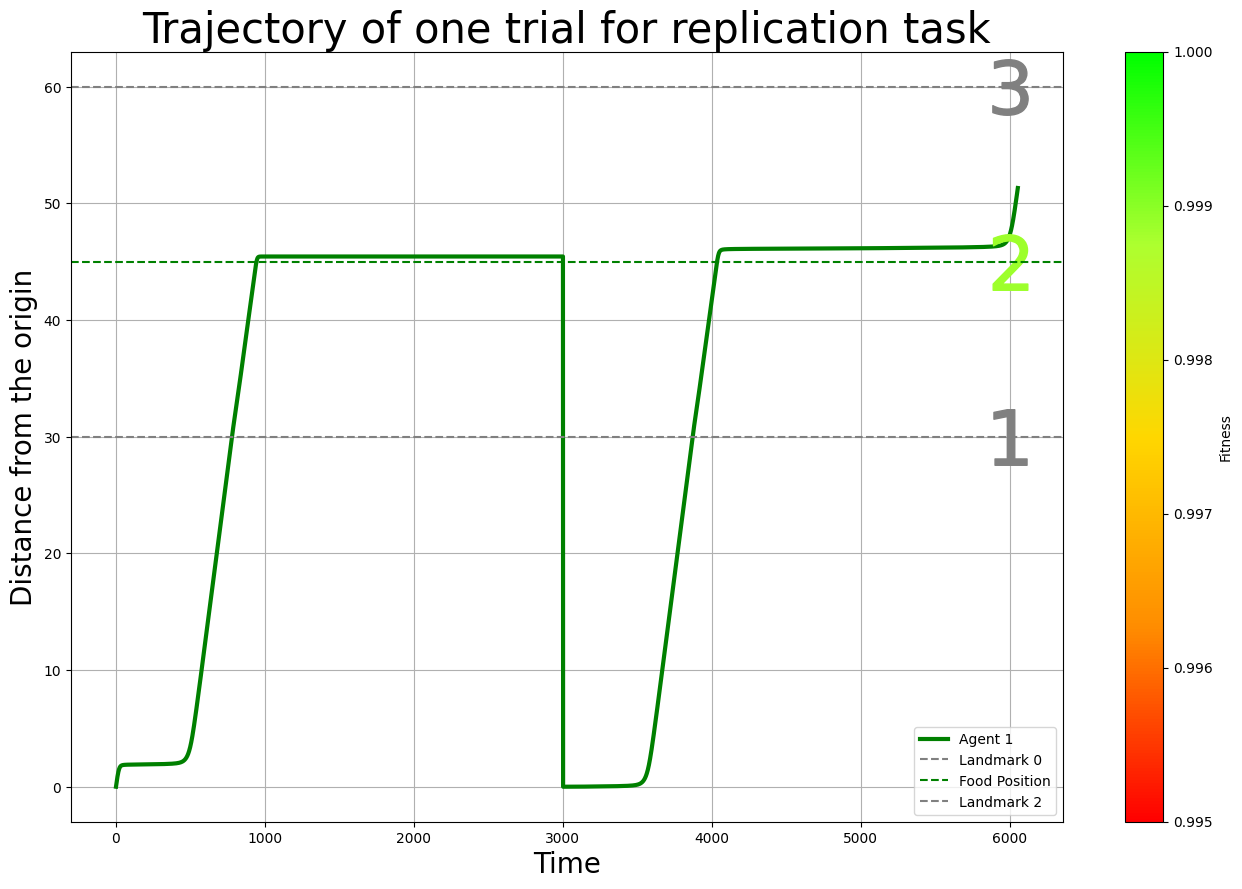

In [ ]:
# the plot for a single run, batch and env with only one delay
batch = 11
stage = "stage4"
run=0
env=2
counter = 14

# then plot phase 3 in a 3x3 grid
# fig, axes = plt.subplots(3, 3, figsize=(15,12), sharey=True)

fig, ax = plt.subplots(figsize=(16,10))

# first plot phase 1 and phase 2 in the same plot
phase1_dir = result_dir + f"batch_{batch}/run_{run}/behavior_{run}_Env{env}_{stage}_Phase1.dat"
phase2_dir = result_dir + f"batch_{batch}/run_{run}/behavior_{run}_Env{env}_{stage}_Phase2.dat"
landmark_file = result_dir+ f"batch_{batch}/run_{run}/landmark_location_{run}_env{env}_{stage}_phase2.dat"
fitness_file = result_dir+ f"batch_{batch}/run_{run}/fitness_{run}_env{env}_{stage}.dat"

behavior = []
behavior.extend(read_ith_line(1, phase1_dir))

# the behaviour
behavior.extend(read_ith_line(counter, phase2_dir))
behaviour_x = list(range(0, len(behavior)))
ax.plot(behaviour_x, behavior, label=f"Agent 1", color="green", linewidth = '3')

fitness = read_ith_line(counter, fitness_file)
print(fitness[len(fitness)-1])

color = getColor(fitness[len(fitness)-1])

# the landmark
landmark = read_ith_line(counter, landmark_file)
landmarks = [0,1,2]
for i in landmarks:
    if (i !=env-1):
        ax.plot(6000,landmark[i], 'go', marker=f"${str(i+1)}$",markersize=40, color="grey")
        ax.axhline(y=landmark[i], linestyle="--", label=f"Landmark {i}", color="grey")
    else:
        ax.plot(6000,landmark[i], 'go',marker=f"${str(i+1)}$",markersize=40,color=color)
        ax.axhline(y=landmark[i], linestyle="--", label="Food Position", color="green")

ax.set_ylabel("Distance from the origin", fontsize=20)
ax.set_xlabel("Time", fontsize=20)
ax.grid(True)
ax.legend()
ax.set_title(f"Trajectory of one trial for replication task", fontsize=30) 
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Fitness")


In [ ]:
# the plot for a single run, batch and env with only one delay
batch = 9
stage = "stage4"
run=0
env=3

# then plot phase 3 in a 3x3 grid
# fig, axes = plt.subplots(3, 3, figsize=(15,12), sharey=True)

fig, ax = plt.subplots(figsize=(16,10))

batches = [1, 5, 6, 7, 9, 17, 18]

for i in range(0, 9):
    # first plot phase 1 and phase 2 in the same plot
    phase1_dir = result_dir + f"batch_{batch}/run_{run}/behavior_{run}_Env{env}_{stage}_Phase1.dat"
    phase2_dir = result_dir + f"batch_{batch}/run_{run}/behavior_{run}_Env{env}_{stage}_Phase2.dat"
    landmark_file = result_dir+ f"batch_{batch}/run_{run}/landmark_location_{run}_env{env}_{stage}_phase2.dat"
    fitness_file = result_dir+ f"batch_{batch}/run_{run}/fitness_{run}_env{env}_{stage}.dat"

    behavior = []
    behavior.extend(read_ith_line(1, phase1_dir))

    counter = 1

    # the behaviour
    behavior.extend(read_ith_line(1, phase2_dir))
    behaviour_x = list(range(0, len(behavior)))
    ax.plot(behaviour_x, behavior, label=f"Agent 1", color="green", linewidth = '3')

    fitness = read_ith_line(counter, fitness_file)
    print(fitness[len(fitness)-1])

    color = getColor(fitness[len(fitness)-1])

    # the landmark
    landmark = read_ith_line(1, landmark_file)
    landmarks = [0,1,2]
    for i in landmarks:
        if (i !=env-1):
            ax.plot(6000,landmark[i], 'go', marker=f"${str(i+1)}$",markersize=40, color="grey")
            # ax.axhline(y=landmark[i], linestyle="--", label=f"Landmark {i}", color="grey")
        else:
            ax.plot(6000,landmark[i], 'go',marker=f"${str(i+1)}$",markersize=40,color=color)
            # ax.axhline(y=landmark[i], linestyle="--", label="Food Position", color="green")

    # fitness
    # fitness = read_ith_line(counter, fitness_file)
    # fitness_start = (len(behaviour) - len(fitness))
    # fitness_x = range(offset+fitness_start, offset+len(fitness)+fitness_start)

    # ax2.plot(fitness_x, fitness, linestyle="dashdot", color="purple")

ax.set_ylabel("Distance from the origin", fontsize=20)
ax.set_xlabel("Time", fontsize=20)
ax.grid(True)
ax.legend()
ax.set_title(f"Trajectory of one trial for replication task", fontsize=40) 
